# Positional Attention

In this notebook, we fix the limitation discussed at the end of the
previous notebook. To add positional encoding, we create another embedder
that takes in the index of the position and spits out a d_model sized vector.
We then add this position vector to the original embedded vector to get a 
new hidden vector. 

You might realize that we now have to have a context size. Since the positional
embedder is just a matrix that is d_model x num_positions, we need to limit
the max number of positions. We do this by defining a max context_size.

Also note that for training, we should ensure that seq_len matches context_size
for at least some if not all batches. This is to ensure all indices for 
the positional encoder get trained.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import tqdm
from matplotlib import pyplot as plt
import random
import os

In [3]:
# Load the data, using tiny shakespeare
input_file_path = '../data/tinyshakespeare.txt'
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

if not os.path.exists(input_file_path):
    with open(input_file_path, 'w') as f:
        f.write(requests.get(data_url).text)
    
with open(input_file_path, 'r') as f:
    corpus = f.read()

In [4]:
# Character level "tokenizer"
unique_chars = sorted(list(set(corpus)))

stoi = {ch: i for i, ch in enumerate(unique_chars)} # str to int
itos = {i: ch for i, ch in enumerate(unique_chars)} # int to str

def encode(text: str) -> list[int]:
    return [stoi[char] for char in text]

def decode(tokens: list[int]) -> str:
    return ''.join([itos[token] for token in tokens])

# Encode the corpus and convert to tensor
data = torch.tensor(encode(corpus), dtype=torch.long)

In [5]:
# Split the data
n = len(data)
train_frac = int(0.9 * n)
train_data = data[:train_frac]
test_data = data[train_frac:]

In [6]:
# Get batches
def get_batch(data, batch_size: int, seq_len: int):
    """Get a batch of (x, y) data from the corpus

    Args:
        data: 1D tensor of torch.long containing the corpus tokens
        batch_size (int): The number of samples to get
        seq_len (int): The length of each sequence to fetch
        
    Returns:
        X: a 2D tensor of shape (batch_size, seq_len) containing token IDs
        Y: a 2D tensor of shape (batch_size, seq_len) containing token IDs
    """
    n = len(data)
    if seq_len > n:
        raise ValueError('seq_len is larger than size of corpus')
    
    start_idxs = torch.randint(n - seq_len, (batch_size,))
    start_idxs = start_idxs[:, None]
    range_idxs = torch.arange(seq_len + 1)
    idxs = start_idxs + range_idxs
    
    values = data[idxs]
    X, Y = values[:, :-1], values[:, 1:]
    return X, Y

In [7]:
# Create the Model
class SingleHeadAttentionPositional(nn.Module):
    def __init__(self, vocab_size, d_model, context_size):
        """
        Args:
            vocab_size (int): Vocabulary size
            d_model (int): Length of the hidden vector after embedding
            context_size (int): The max context size 
        """
        super().__init__()
        
        # Embedding
        self.embed = nn.Embedding(vocab_size, d_model)
        
        # Positional Encoder
        self.context_size = context_size
        self.pos_encoder = nn.Embedding(context_size, d_model)
        
        # Attention
        self.head_dim = d_model
        self.w_q = nn.Linear(d_model, self.head_dim, bias=False) # Query 
        self.w_k = nn.Linear(d_model, self.head_dim, bias=False) # Key
        self.w_v = nn.Linear(d_model, self.head_dim, bias=False) # Value
        
        # Unembedding
        self.unembed = nn.Linear(self.head_dim, vocab_size, bias=False)
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len) that contains
            the token ids for each token
            
        Returns:
            A tensor of shape (batch_size, seq_len, vocab_size) of logits
        """
        # Check seq_len size
        if x.shape[1] > self.context_size:
            raise ValueError('The sequence length is larger than the max context size')
        
        # Embedding
        x_embeded = self.embed(x) # (batch_size, seq_len, d_model)
        
        # Positional Encoding
        positions = torch.arange(x.shape[1]).expand(x.shape[0], x.shape[1])
        positions_encoded = self.pos_encoder(positions)
        
        # Combine
        hidden = x_embeded + positions_encoded
        
        # Construct q, k, v matrices
        q = self.w_q(hidden) # (batch_size, seq_len, head_dim)
        k = self.w_k(hidden)
        v = self.w_v(hidden)
        
        # Similarity matrix
        sim = q @ k.transpose(-2, -1) # (batch_size, seq_len, seq_len)
        sim = 1 / np.sqrt(self.head_dim) * sim
        
        # Apply causal mask
        seq_len = sim.shape[-1]
        mask = torch.tril(torch.ones(seq_len, seq_len)) # Lower triangular
        sim.masked_fill_(mask == 0, float('-inf'))
        
        # Softmax
        sim = F.softmax(sim, dim=-1)
        
        # Output
        output = sim @ v
        
        # Unembedding
        unembeded = self.unembed(output)
        return unembeded

In [8]:
# Train the model
vocab_size = len(unique_chars)
batch_size = 64
seq_len = 128
d_model = 64
total_steps = 7000
context_size = seq_len

model = SingleHeadAttentionPositional(vocab_size, d_model, context_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.e-3)

losses = []
seq_done = 0

pbar = tqdm.tqdm(range(total_steps))
for step in pbar:
    x, y = get_batch(train_data, batch_size, seq_len)
    optimizer.zero_grad()
    
    logits = model(x)
    logits = logits.reshape(-1, logits.size(-1))
    y = y.reshape(-1)
    
    loss = criterion(logits, y)
    loss.backward()
    
    losses.append(loss.item())
    seq_done += batch_size
    
    pbar.set_description(f'Loss: {loss.item():.4f}, Sequences Done: {seq_done}')
    
    optimizer.step()
    

Loss: 2.3141, Sequences Done: 448000: 100%|██████████| 7000/7000 [00:35<00:00, 198.79it/s]


Text(0, 0.5, 'Loss')

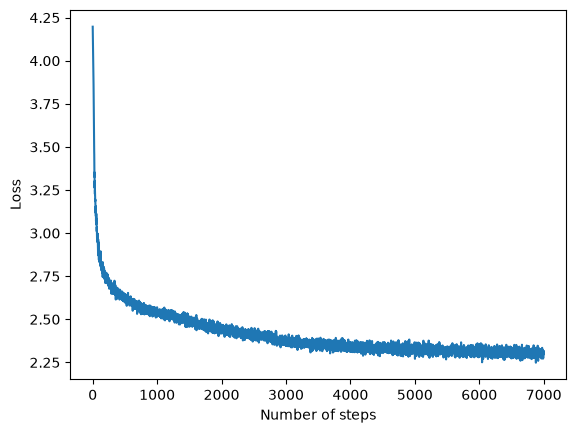

In [9]:
# Graph the results
plt.plot(np.linspace(0, total_steps-1, total_steps), losses)
plt.xlabel('Number of steps')
plt.ylabel('Loss')

In [10]:
# Autoregressive generation
tokens_to_gen = 200
random_char = unique_chars[random.randint(0, vocab_size-1)]
start_token = encode(random_char)[0]

generated_tokens = []
generated_tokens.append(start_token)

for _ in range(tokens_to_gen-1):
    with torch.no_grad():
        logits = model(torch.tensor(generated_tokens[-context_size:]).reshape(1, -1))
        logits = logits[0, -1, :] # (vocab,)
        probs = F.softmax(logits, dim=-1)
        token = torch.multinomial(probs, num_samples=1) # Sampling
        generated_tokens.append(token.item())
    
decode(generated_tokens)

'uth hhro west, youll I hime illig.\n\nOlos th adicomaly:\nShe it se thoush thawe cort inelileness sicene deth cmot gont the winter OF:\nI now mere mincake thonke I of of, her:\nWist the sth cot ey of dary '

Notice that the difference in loss from 02 to 03 is significantly greater than the loss from 01 to 02. That is, adding positions decreased loss significantly more than just regular attention did to the bigram. Note we are currently only
viewing training loss because we want the model to get the ability
to overfit. 